In [251]:
from pathlib import Path

import matplotlib.pyplot as plt
import cv2
import numpy as np

from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks

THRESHOLD = 127


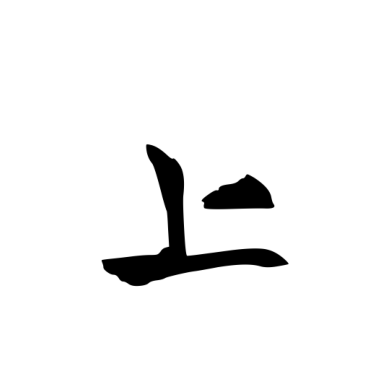

In [252]:
image_path = "../000-dataset/Longcang/4E0A.png"
THRESHOLD = 127
image = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)

plt.imshow(image, cmap="gray")
plt.axis("off")
plt.show()



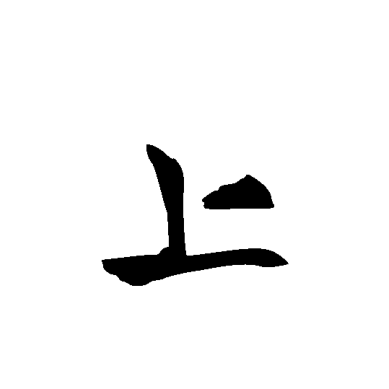

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], shape=(512, 512), dtype=uint8)

In [253]:
binary = cv2.threshold(image, THRESHOLD, 255, cv2.THRESH_BINARY)[1]
plt.imshow(binary, cmap="gray")
plt.axis("off")
plt.show()

binary

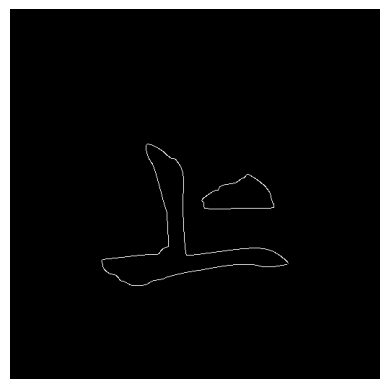

In [254]:
edge = cv2.Canny(binary, 100, 200)
plt.imshow(edge, cmap="gray")
plt.axis("off")
plt.show()

In [255]:
contours, hierarchy = cv2.findContours(edge, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

for i, contour in enumerate(contours):
    print(
        i,
        contour.shape,
        cv2.contourArea(contour)
    )

0 (85, 1, 2) 3137.5
1 (548, 1, 2) 44.5


In [256]:
contour_image = np.ones(
    (512, 512, 3), dtype=np.uint8
) * 255

cv2.drawContours(
    contour_image,
    contours,
    -1,
    (0, 0, 0),
    1
)


array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]

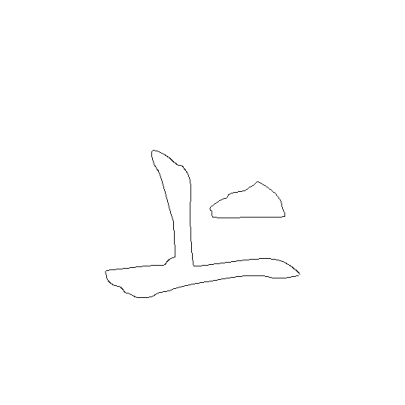

In [257]:
plt.figure(figsize=(5, 5))
plt.imshow(contour_image)
plt.axis("off")
plt.show()

In [258]:
longest_contour = max(
    contours,
    key=lambda x: len(x)
)

longest_contour.shape

(548, 1, 2)

In [259]:
contour1 = longest_contour[:, 0, :]

x, y = contour1[:, 0].astype(int), contour1[:, 1].astype(int)

print(x[:10])
print(y[:10])

[190 188 188 189 189 190 190 191 191 192]
[186 188 195 196 199 200 202 203 205 206]


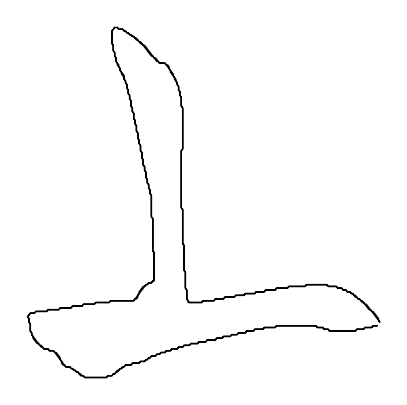

In [ ]:
plt.figure(figsize=(5, 5))

plt.plot(x, y, color="black", linewidth=1)

plt.gca().invert_yaxis()

plt.axis("off")
plt.show()

In [261]:
dx, dy = np.gradient(x), np.gradient(y)
print(dx[:10])
print(dy[:10])

ddx, ddy = np.gradient(dx), np.gradient(dy)
print(ddx[:10])
print(ddy[:10])

[-2.  -1.   0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5]
[2.  4.5 4.  2.  2.  1.5 1.5 1.5 1.5 1. ]
[1.   1.25 0.75 0.   0.   0.   0.   0.   0.   0.25]
[ 2.5   1.   -1.25 -1.   -0.25 -0.25  0.    0.   -0.25  0.  ]


In [262]:
numerator = np.abs(
    dx * ddy - dy * ddx
)

denominator = (dx ** 2 + dy ** 2) ** 1.5

denominator[denominator < 1e-8] = 1e-8

curvature = numerator / denominator

print(curvature[:10])

[0.30935922 0.06763126 0.05533857 0.05706721 0.0142668  0.03162278
 0.         0.         0.03162278 0.17888544]


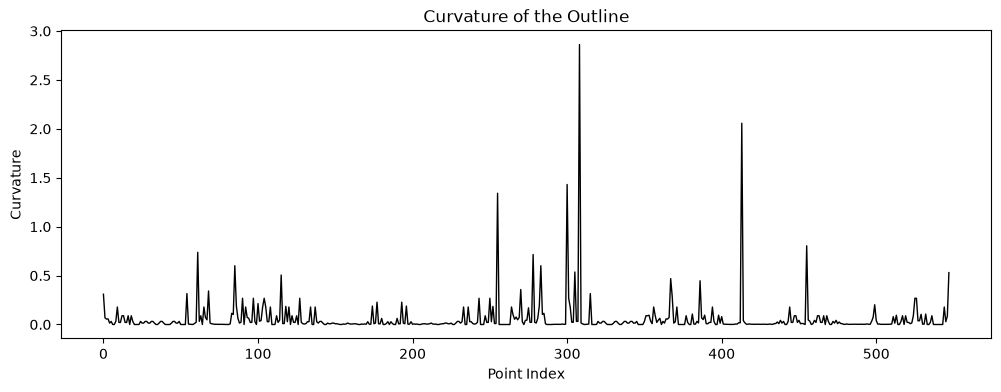

In [263]:
plt.figure(figsize=(12,4))

plt.plot(curvature, color="black", linewidth=1)
plt.xlabel("Point Index")
plt.ylabel("Curvature")
plt.title("Curvature of the Outline")
plt.show()

In [264]:
curvature_sum = np.sum(curvature)
print(f"Sum of curvature: {curvature_sum}")

Sum of curvature: 32.97314423602255


In [265]:
SIGMA = 1
smooth_curvature = gaussian_filter1d(
    curvature,
    sigma=SIGMA,
    mode="wrap"
)

peak, properties = find_peaks(
    smooth_curvature
)

print(peak[:10])
print(len(peak))

feature_points = contour1[peak]
print(feature_points[:10])



[ 9 12 16 18 28 31 37 46 54 61]
81
[[192 206]
 [194 210]
 [197 215]
 [198 217]
 [203 233]
 [205 238]
 [208 249]
 [212 266]
 [216 279]
 [217 329]]


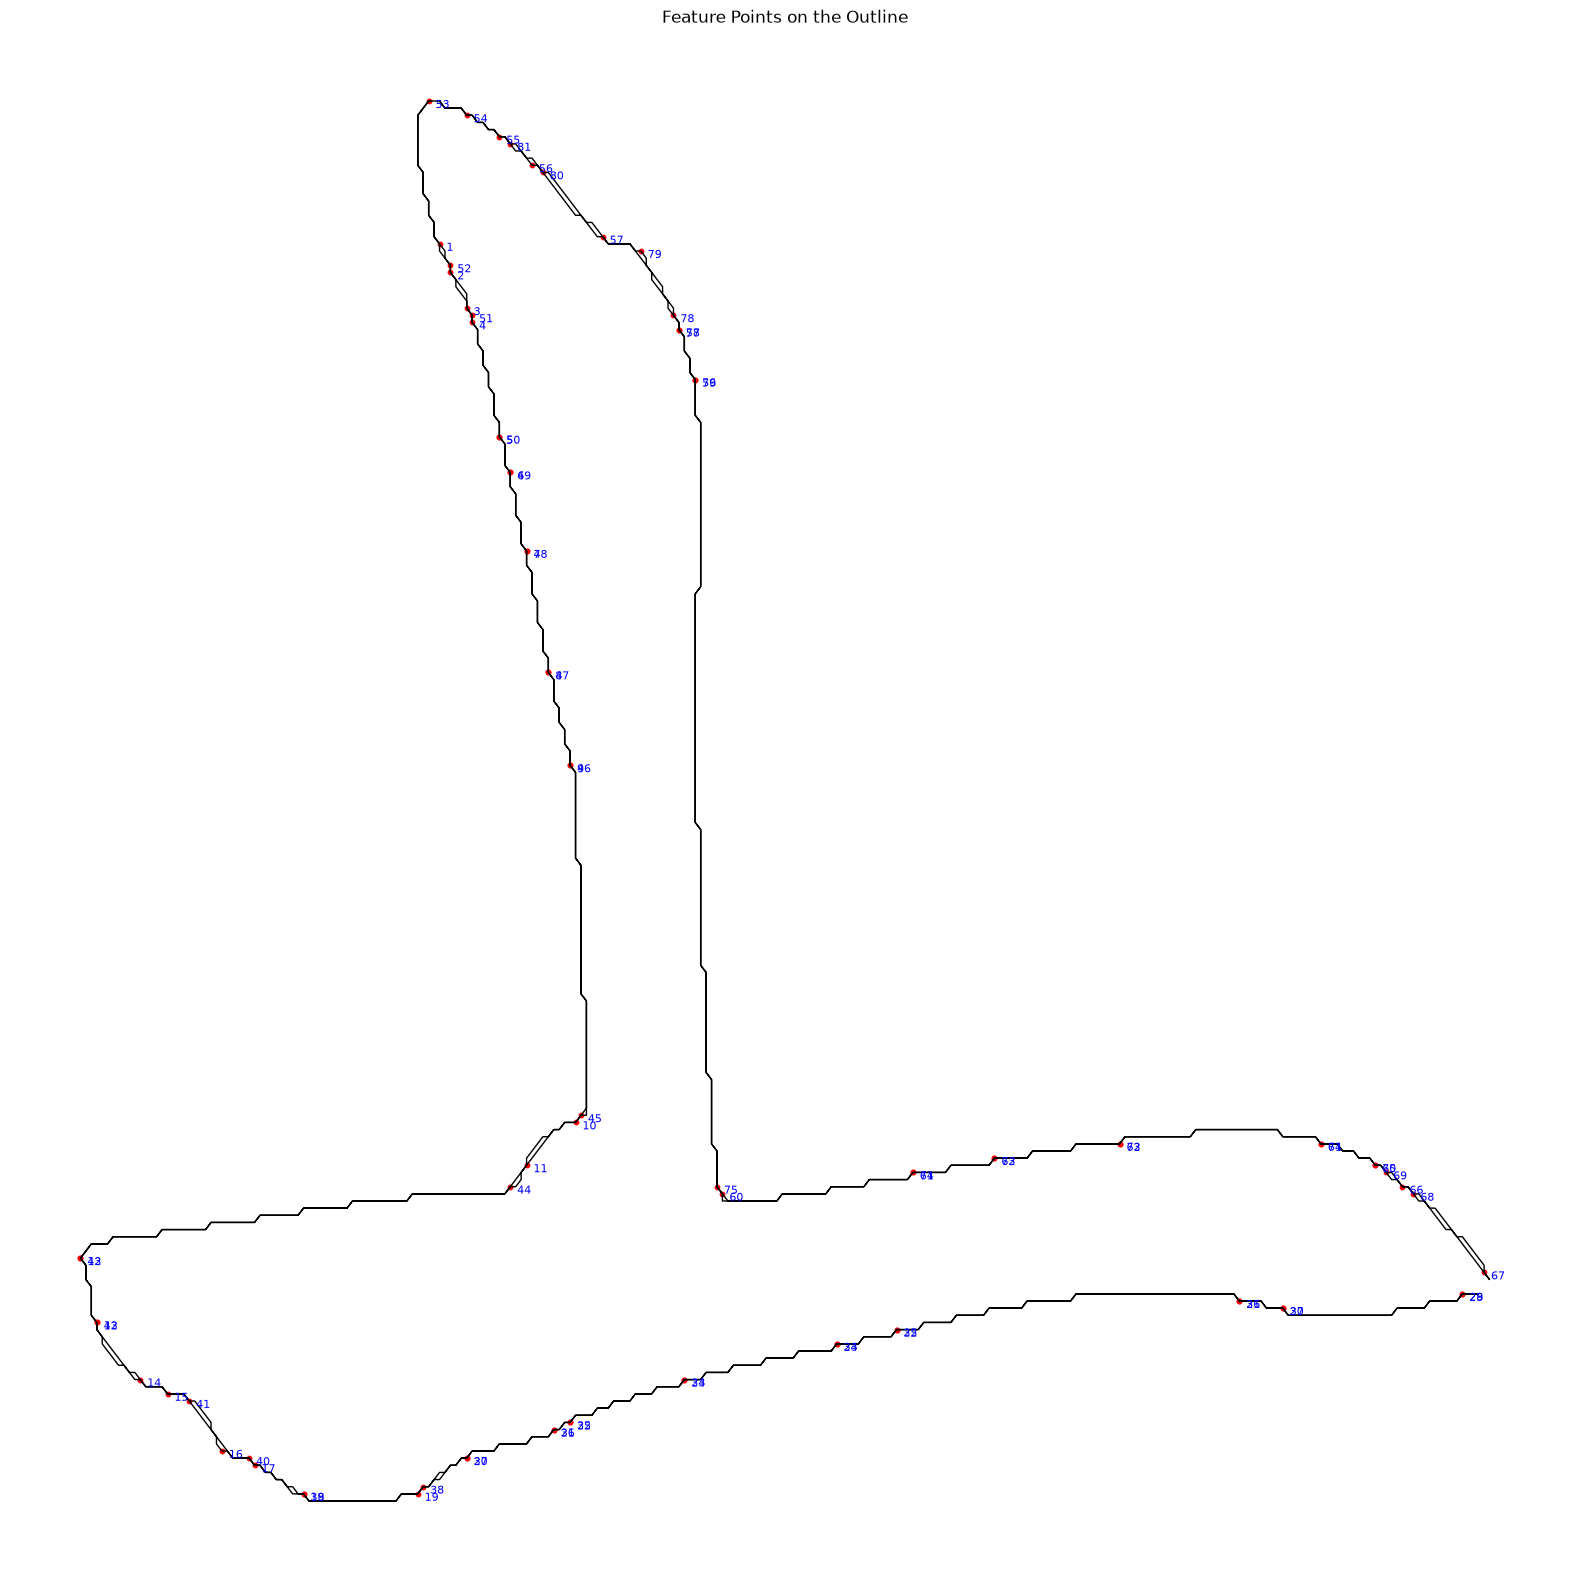

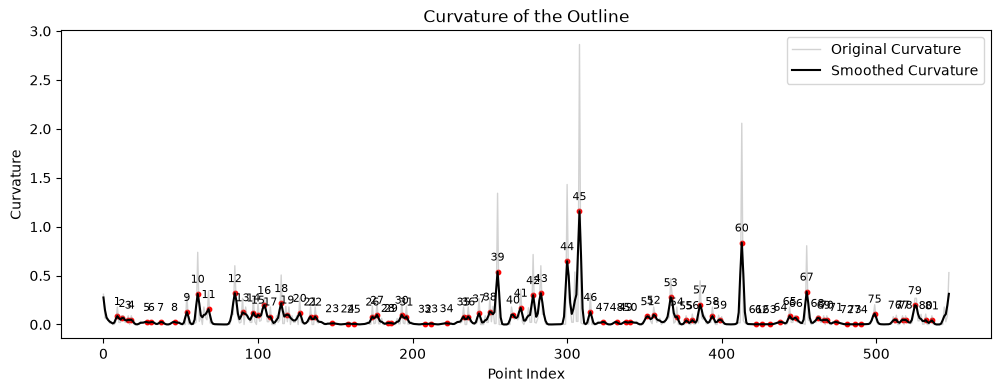

In [266]:
plt.figure(figsize=(20,20))

plt.plot(x, y, color="black", linewidth=1)

plt.scatter(
    feature_points[:, 0],
    feature_points[:, 1],
    color="red",
    s=10
)

for i, (fx, fy) in enumerate(feature_points):
    plt.annotate(
        f"{i+1}",
        xy=(fx, fy),
        xytext=(5, -5),
        textcoords="offset points",
        fontsize=8,
        color="blue"
    )

plt.gca().invert_yaxis()
plt.axis("off")
plt.title("Feature Points on the Outline")
plt.show()

plt.figure(figsize=(12, 4))

# 原始曲率：淡色
plt.plot(
    curvature,
    color="gray",
    linewidth=1,
    alpha=0.35,
    label="Original Curvature"
)

# Gaussian 平滑后的曲率：主线
plt.plot(
    smooth_curvature,
    color="black",
    linewidth=1.5,
    label="Smoothed Curvature"
)

for i, p in enumerate(peak):
    plt.scatter(
        p,
        smooth_curvature[p],
        color="red",
        s=10
    )
    plt.annotate(
        f"{i+1}",
        xy=(p, smooth_curvature[p]),
        xytext=(0, 8),
        textcoords="offset points",
        fontsize=8,
        ha="center"
    )

plt.xlabel("Point Index")
plt.ylabel("Curvature")
plt.title("Curvature of the Outline")
plt.legend()
plt.show()

In [267]:
angles = []

for i in range(len(feature_points)):
    p1 = feature_points[i - 1]
    p2 = feature_points[i]
    p3 = feature_points[(i + 1) % len(feature_points)]

    v1 = p1 - p2
    v2 = p3 - p2

    numerator = np.dot(v1, v2)
    denominator = np.linalg.norm(v1) * np.linalg.norm(v2)
    denominator = np.clip(denominator, 1e-8, None)
    
    cos_angle = numerator / denominator
    angle = np.arccos(np.clip(cos_angle, -1.0, 1.0))
    angles.append(np.degrees(angle))


angles = np.array(angles)
print(len(angles))
print(angles)

81
[110.55604522 175.60129465 175.60129465 170.78897346 175.55261515
 173.45370922 177.98540121 176.13779095 164.04303387 122.54430469
 155.31843622  80.57355492 153.43494882 156.80140949 163.14160123
 159.77514057 174.47245985 156.03751103 150.9453959  164.98163937
 175.60129465 177.51044708 174.17927575 179.81982519 173.32810427
 169.24203291 169.40675439  90.          90.         169.40675439
 169.24203291 173.32810427 179.81982519 174.17927575 177.51044708
 175.60129465 167.47119229 156.03751103 150.83238662 170.53767779
 176.87786954 141.34019175  78.77931322 149.64567001 125.23128617
 165.23457689 176.13779095 177.98540121 173.45370922 174.58813085
 166.64465904 160.12092565  64.18879716 169.38034472 172.87498365
 176.1214755  174.68968843 156.07749412 159.31277275  87.61227081
 177.30444909 177.37509736 175.03025927 163.30075577 165.7354877
 172.30394828   1.57655006 170.72739822 175.60129465 170.13419306
 163.30075577 175.03025927 177.37509736 175.58518675  88.84749258
 158.828

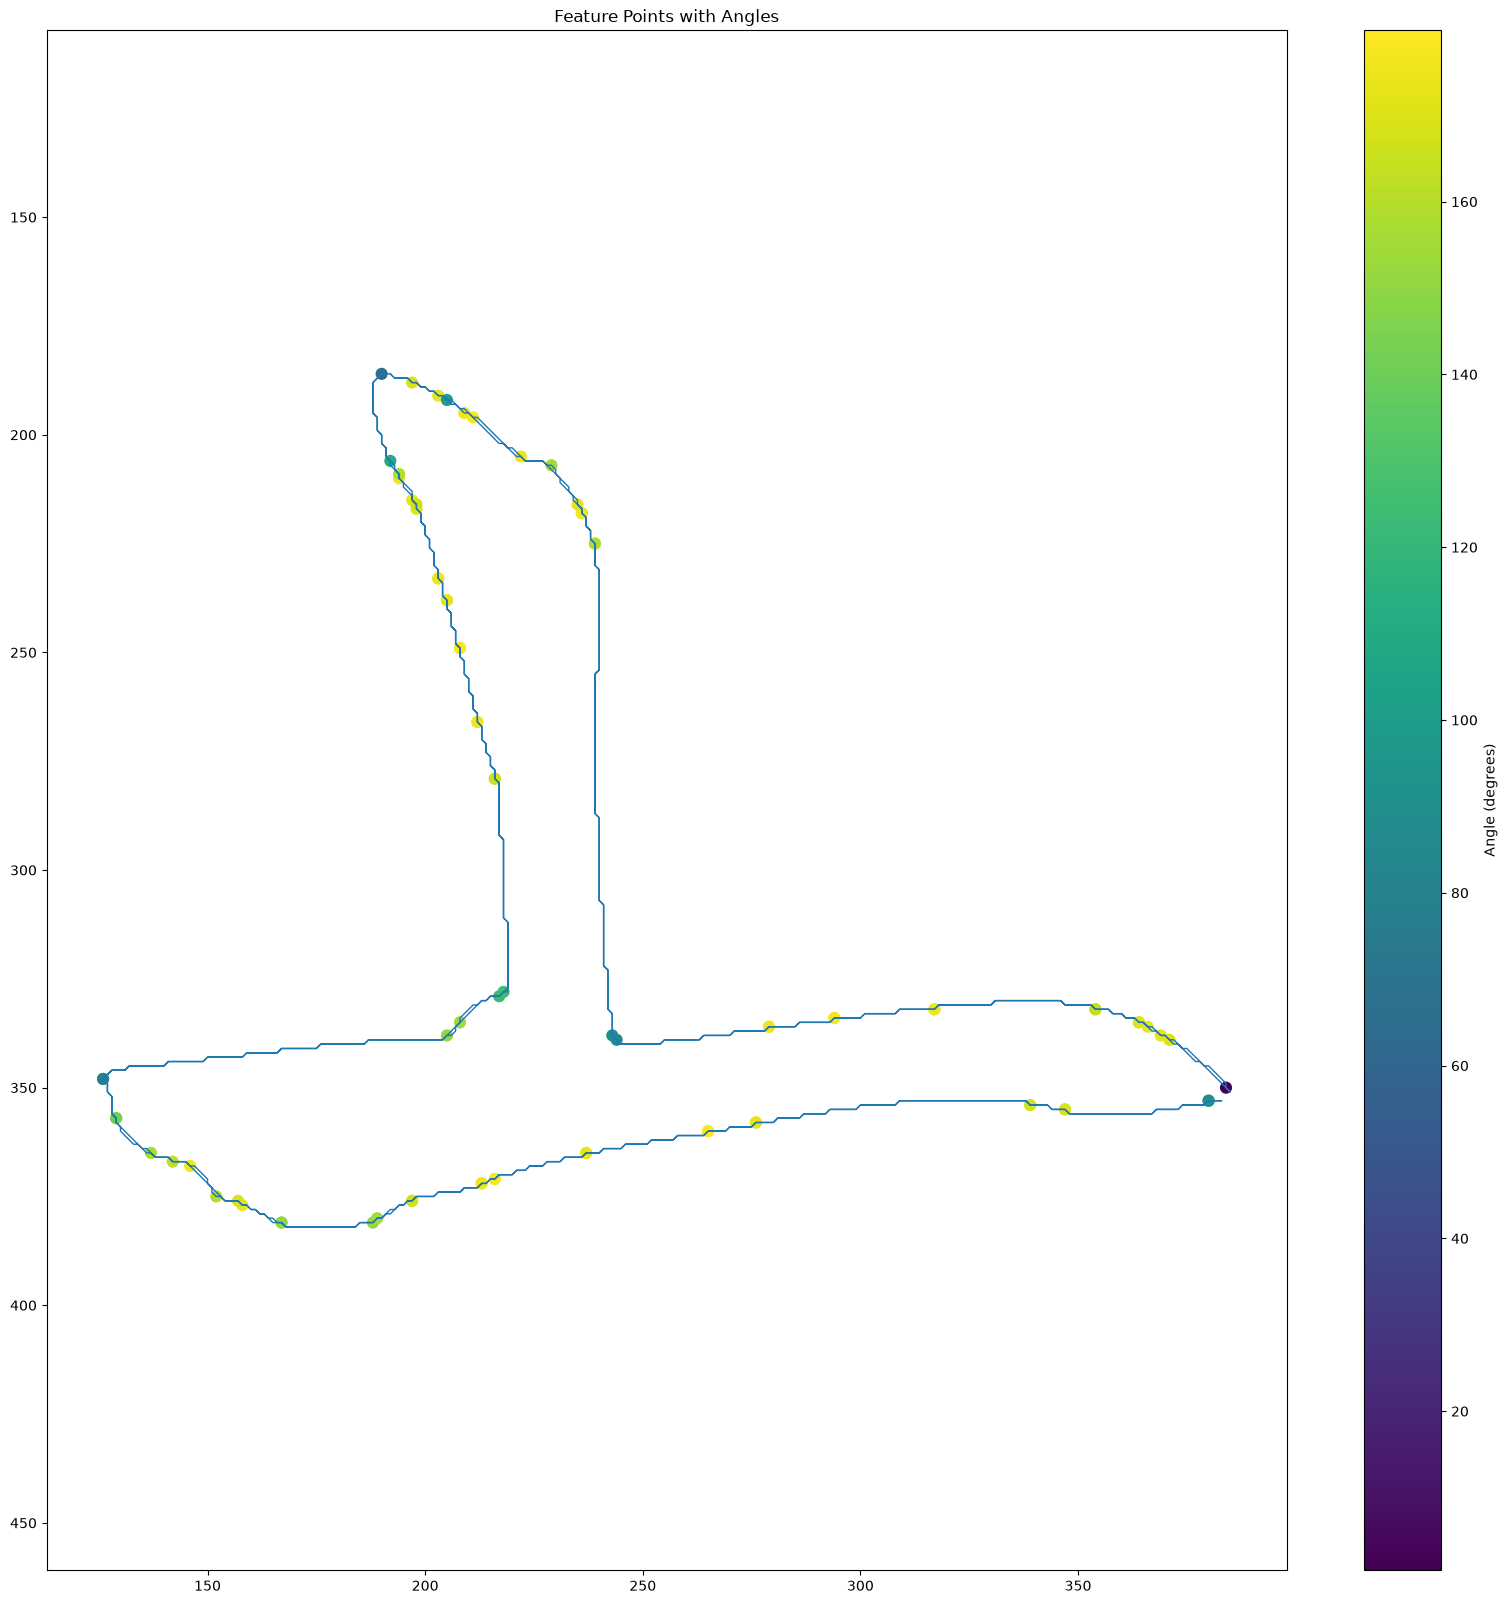

In [268]:
plt.figure(figsize=(20,20))

plt.plot(
    x, y,
    linewidth=1
)

scatter = plt.scatter(
    feature_points[:, 0],
    feature_points[:, 1],
    c=angles,
    s=60
)

plt.colorbar(
    scatter,
    label="Angle (degrees)"
)

plt.gca().invert_yaxis()
plt.axis("equal")

plt.title("Feature Points with Angles")
plt.show()

In [269]:
sorted_indeces = np.argsort(angles)

sorted_angles = angles[sorted_indeces]


print(sorted_angles[:10])

[  1.57655006  64.18879716  78.77931322  80.57355492  87.61227081
  88.84749258  90.          90.          99.18883608 110.55604522]


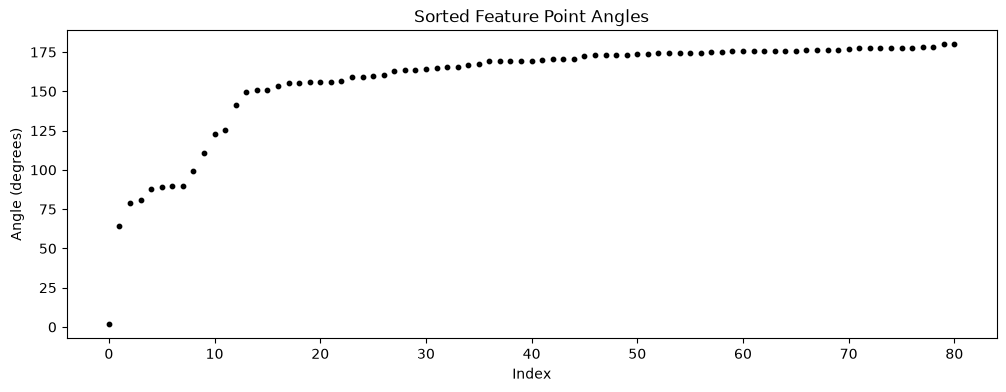

In [270]:
angle_x = np.arange(len(sorted_angles))

plt.figure(figsize=(12, 4))
plt.scatter(
    angle_x,
    sorted_angles,
    color="black",
    s=10
)
plt.xlabel("Index")
plt.ylabel("Angle (degrees)")
plt.title("Sorted Feature Point Angles")
plt.show()

In [271]:
x1, y1 = angle_x[0], sorted_angles[0]
x2, y2 = angle_x[-1], sorted_angles[-1]


principal_axis = (y1 +(y2-y1)/(x2-x1)*(angle_x-x1))
print(principal_axis[:10])

[ 1.57655006  3.80459099  6.03263193  8.26067287 10.48871381 12.71675475
 14.94479569 17.17283663 19.40087757 21.62891851]


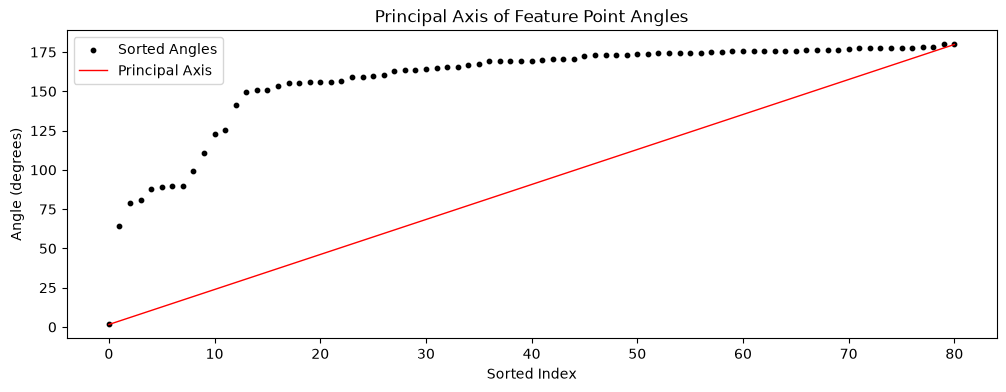

In [272]:
plt.figure(figsize=(12, 4))
plt.scatter(
    angle_x,
    sorted_angles,
    color="black",
    s=10,
    label="Sorted Angles"
)

plt.plot(
    angle_x,
    principal_axis,
    color="red",
    linewidth=1,
    label="Principal Axis"
)

plt.xlabel("Sorted Index")
plt.ylabel("Angle (degrees)")

plt.legend()
plt.title("Principal Axis of Feature Point Angles")
plt.show()

In [273]:
A = y2 - y1
B = x1 - x2
C = x2 * y1 - x1 * y2

distances = np.abs(A * angle_x + B * sorted_angles + C) / np.sqrt(A**2 + B**2)

print(distances[:10])

print(angle_x.shape)
print(distances.shape)

[ 0.         24.72569367 29.78779173 29.61016271 31.58000355 31.17347105
 30.73306926 29.82074696 32.67100366 36.41324502]
(81,)
(81,)


Text(0.5, 1.0, 'Distances of Feature Points to Principal Axis')

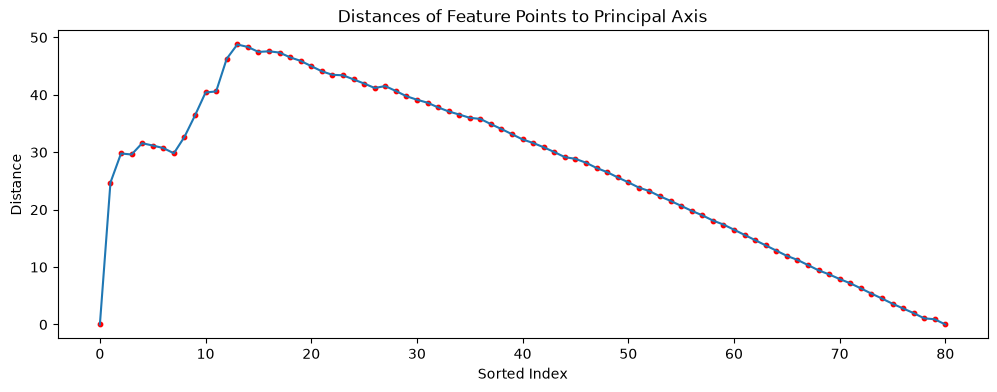

In [274]:
plt.figure(figsize=(12, 4))
plt.plot(
    angle_x,
    distances,
)
plt.scatter(
    angle_x,
    distances,
    color="red",
    s=10,
    label="Distances to Principal Axis"
) 

plt.xlabel("Sorted Index")
plt.ylabel("Distance")
plt.title("Distances of Feature Points to Principal Axis")

In [275]:
max_distance_index = np.argmax(distances)
max_distance = distances[max_distance_index]

print(f"Max distance: {max_distance} at index {max_distance_index}")

Max distance: 48.77009632917812 at index 13


In [276]:
angle_threshold = sorted_angles[max_distance_index]

print(f"Angle threshold: {angle_threshold}")

Angle threshold: 149.64567001037926


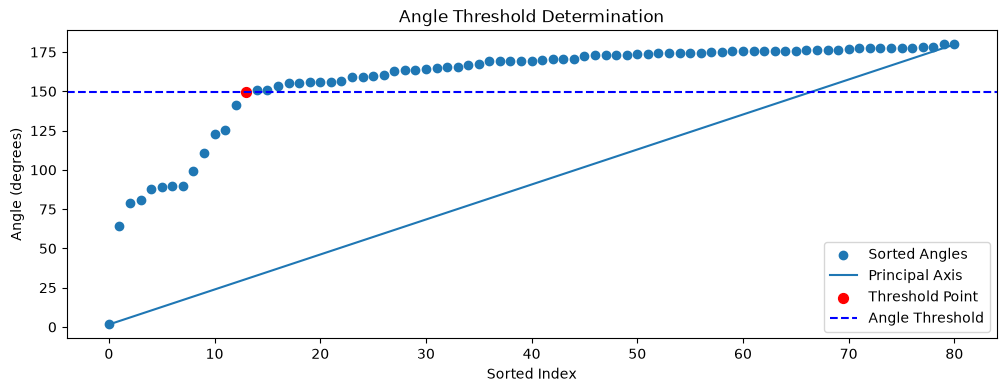

In [277]:
plt.figure(figsize=(12, 4))

plt.scatter(
    angle_x,
    sorted_angles,
    label="Sorted Angles"
)

plt.plot(
    angle_x,
    principal_axis,
    label="Principal Axis"
)

plt.scatter(
    max_distance_index,
    angle_threshold,
    s=50,
    color="red",
    label="Threshold Point"
)

plt.axhline(
    angle_threshold,
    linestyle="--",
    color="blue",
    label="Angle Threshold"
)

plt.xlabel("Sorted Index")
plt.ylabel("Angle (degrees)")

plt.legend()
plt.title("Angle Threshold Determination")
plt.show()

In [278]:
final_mask = (angles < angle_threshold)
final_feature_points = feature_points[final_mask]

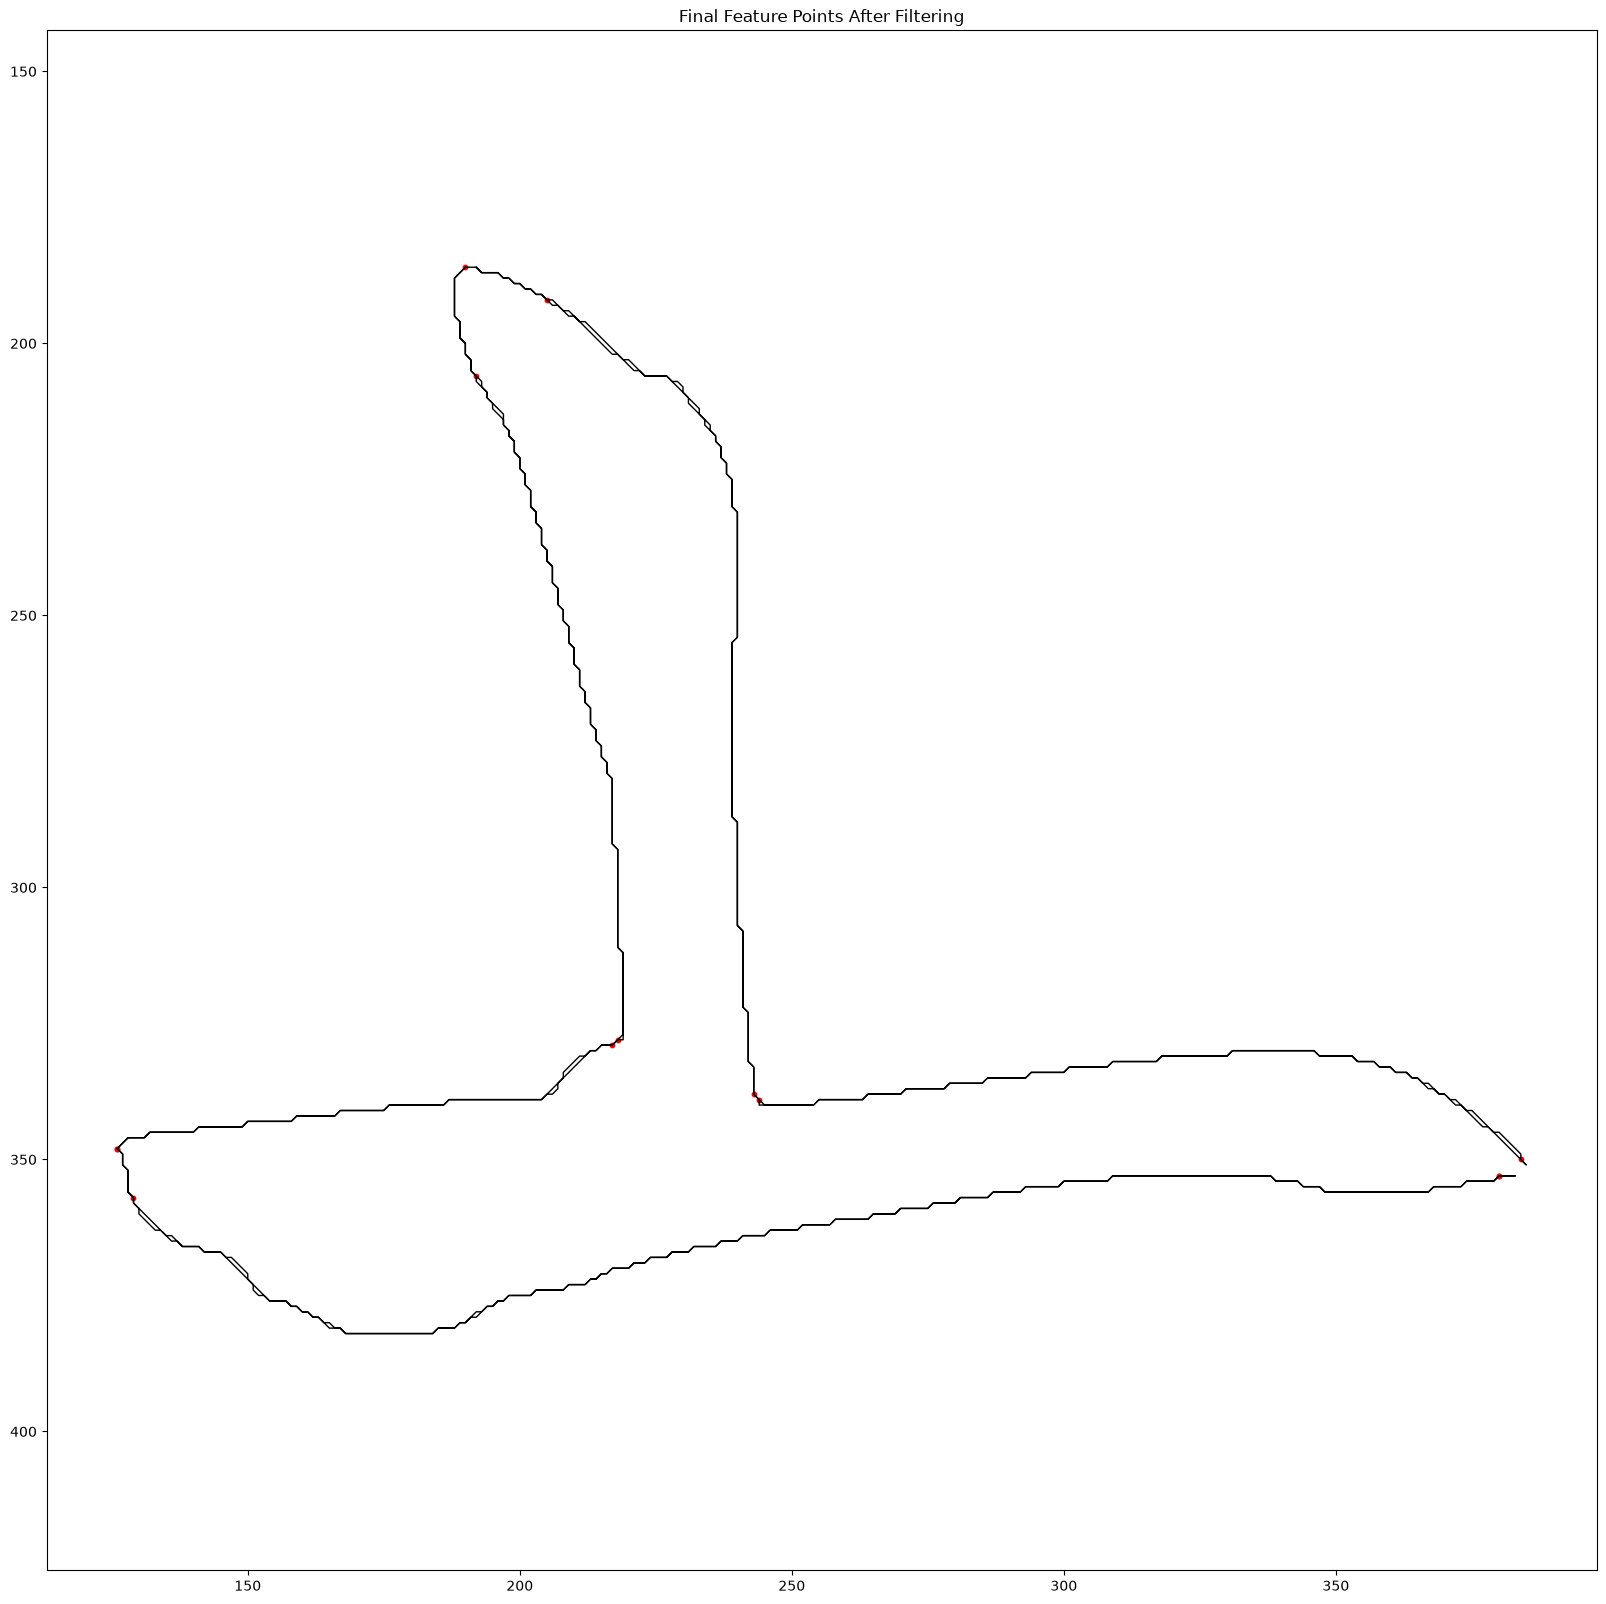

In [279]:
plt.figure(figsize=(20, 20))

plt.plot(x, y, color="black", linewidth=1)

plt.scatter(
    final_feature_points[:, 0],
    final_feature_points[:, 1],
    color="red",
    s=10
)

plt.gca().invert_yaxis()
plt.axis("equal")
plt.title("Final Feature Points After Filtering")
plt.show()

In [280]:
final_peak_indices = peak[final_mask]

start_idx = final_peak_indices[0]
end_idx = final_peak_indices[-1]

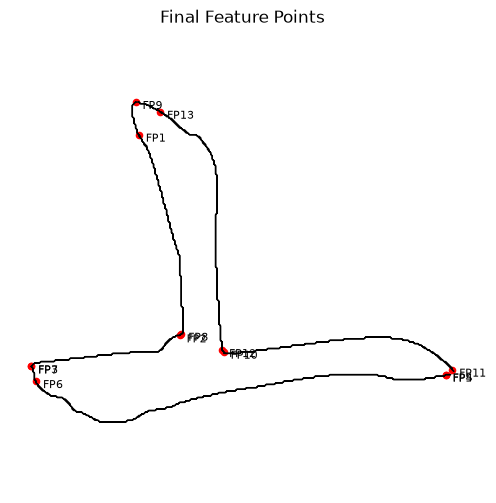

In [281]:
plt.figure(figsize=(6, 6))

plt.plot(
    x, y,
    color="black",
    linewidth=1
)

plt.scatter(
    contour1[final_peak_indices, 0],
    contour1[final_peak_indices, 1],
    color="red",
    s=20
)

for i, idx in enumerate(final_peak_indices):

    px = contour1[idx, 0]
    py = contour1[idx, 1]

    plt.annotate(
        f"FP{i+1}",
        xy=(px, py),
        xytext=(5, -5),
        textcoords="offset points",
        fontsize=8
    )

plt.gca().invert_yaxis()
plt.axis("equal")
plt.axis("off")

plt.title("Final Feature Points")

plt.show()

## Section 4: Contour Segment Approximation

论文在确定 feature points 后，沿闭合轮廓把字符切成 contour segments；每一段先用 chord deviation 衡量弯曲程度，再选择 straight line、quadratic Bézier 或 cubic Bézier。下面继续保持逐步实验的写法。


In [282]:
# 第 46 步：保留最终 feature point 对应的 contour 索引
# peak 是前面 find_peaks 得到的候选点索引，final_mask 是最终筛选掩码。
final_peak_indices = peak[final_mask]
print("Final peak indices:", final_peak_indices)
print("Number of final feature points:", len(final_peak_indices))


Final peak indices: [  9  61  85 184 186 278 283 308 367 413 455 499 536]
Number of final feature points: 13


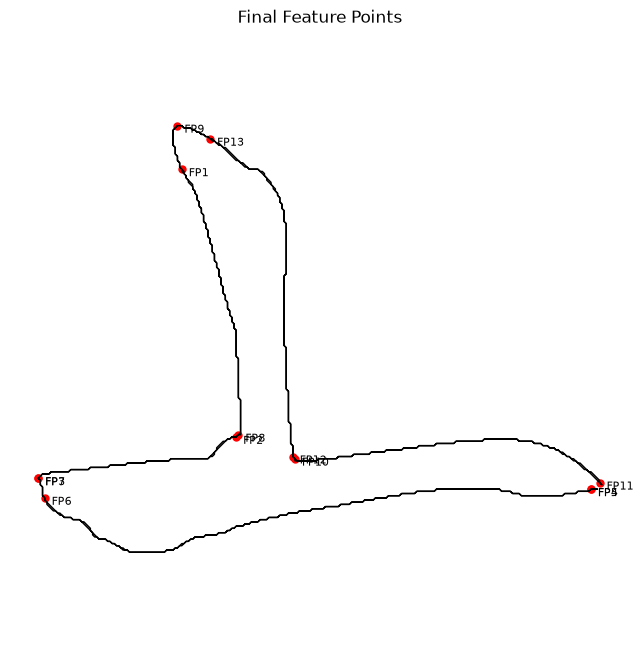

In [283]:
# 第 47 步：重新绘制并标号最终 feature points
plt.figure(figsize=(8, 8))
plt.plot(x, y, color="black", linewidth=1)
plt.scatter(contour1[final_peak_indices, 0], contour1[final_peak_indices, 1], color="red", s=25)
for i, idx in enumerate(final_peak_indices):
    px, py = contour1[idx]
    plt.annotate(f"FP{i+1}", xy=(px, py), xytext=(5, -5), textcoords="offset points", fontsize=8)
plt.gca().invert_yaxis()
plt.axis("equal")
plt.axis("off")
plt.title("Final Feature Points")
plt.show()


In [284]:
# 第 48 步：按照 contour 顺序排序
final_peak_indices = np.sort(final_peak_indices)
print(final_peak_indices)


[  9  61  85 184 186 278 283 308 367 413 455 499 536]


### 第 49 步：闭合 contour 的分段方式

相邻 feature points 之间形成一个 segment；最后一个 feature point 到第一个 feature point 需要跨过数组末尾，再接回数组开头。先对 FP1 → FP2 做完整实验，确认公式和拟合结果后，再批量处理所有 segment。


In [285]:
# 第 50 步：先取 FP1 → FP2
start_idx = final_peak_indices[0]
end_idx = final_peak_indices[1]
segment = contour1[start_idx:end_idx + 1]
print("start_idx =", start_idx)
print("end_idx =", end_idx)
print("segment.shape =", segment.shape)


start_idx = 9
end_idx = 61
segment.shape = (53, 2)


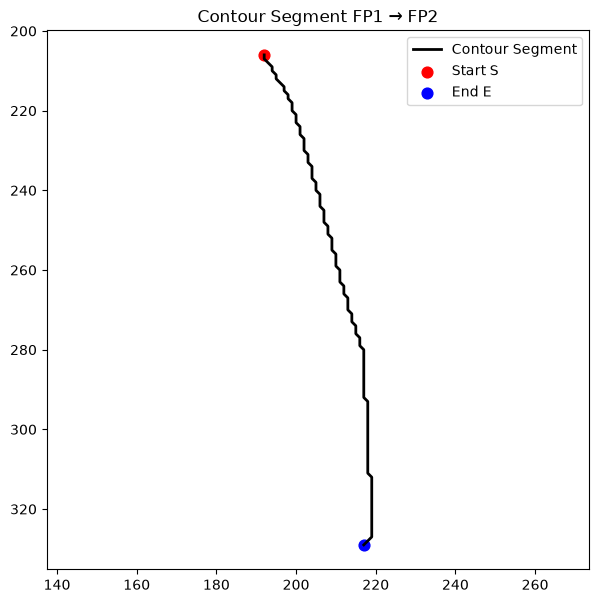

In [286]:
# 第 51 步：单独绘制 contour segment
plt.figure(figsize=(7, 7))
plt.plot(segment[:, 0], segment[:, 1], color="black", linewidth=2, label="Contour Segment")
plt.scatter(*segment[0], color="red", s=60, label="Start S")
plt.scatter(*segment[-1], color="blue", s=60, label="End E")
plt.gca().invert_yaxis()
plt.axis("equal")
plt.legend()
plt.title("Contour Segment FP1 → FP2")
plt.show()


S = [192. 206.]
E = [217. 329.]


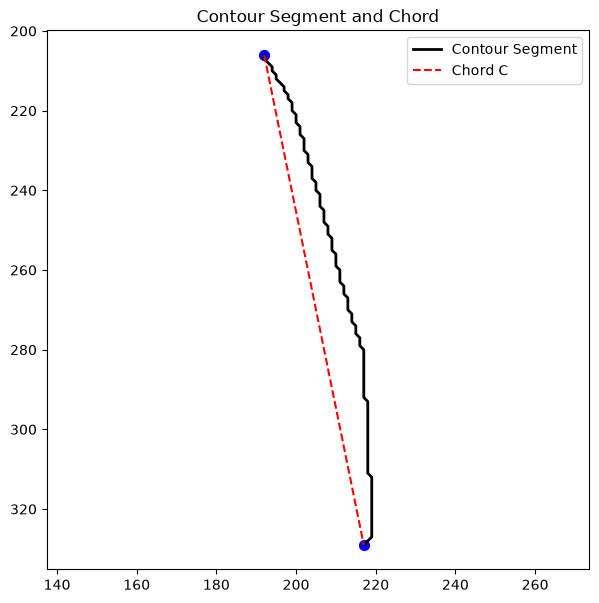

In [287]:
# 第 52–53 步：定义 S、E，并构造 chord C
S = segment[0].astype(np.float64)
E = segment[-1].astype(np.float64)
print("S =", S)
print("E =", E)

plt.figure(figsize=(7, 7))
plt.plot(segment[:, 0], segment[:, 1], color="black", linewidth=2, label="Contour Segment")
plt.plot([S[0], E[0]], [S[1], E[1]], color="red", linestyle="--", label="Chord C")
plt.scatter([S[0], E[0]], [S[1], E[1]], color="blue", s=50)
plt.gca().invert_yaxis()
plt.axis("equal")
plt.legend()
plt.title("Contour Segment and Chord")
plt.show()


### 第 54–58 步：normalized accumulated chord-length parameterization

论文不是按点的编号均匀取参数，而是按 contour 上相邻点的累计长度归一化，令第一个点参数为 0，最后一个点参数为 1。


In [288]:
# 第 55–57 步：相邻长度、累计长度和归一化参数 t
segment_diff = np.diff(segment.astype(np.float64), axis=0)
segment_lengths = np.linalg.norm(segment_diff, axis=1)
accumulated_length = np.concatenate(([0.0], np.cumsum(segment_lengths)))
total_length = accumulated_length[-1]
if total_length == 0:
    raise ValueError("The selected contour segment has zero length.")
t = accumulated_length / total_length
print("segment_lengths[:10] =", segment_lengths[:10])
print("t[:10] =", t[:10])
print("t[0] =", t[0], "t[-1] =", t[-1])


segment_lengths[:10] = [1.         2.82842712 1.         1.41421356 1.         2.82842712
 1.         1.41421356 1.         1.41421356]
t[:10] = [0.         0.00740674 0.02835616 0.0357629  0.04623761 0.05364435
 0.07459376 0.0820005  0.09247521 0.09988195]
t[0] = 0.0 t[-1] = 1.0


chord_points.shape = (53, 2)


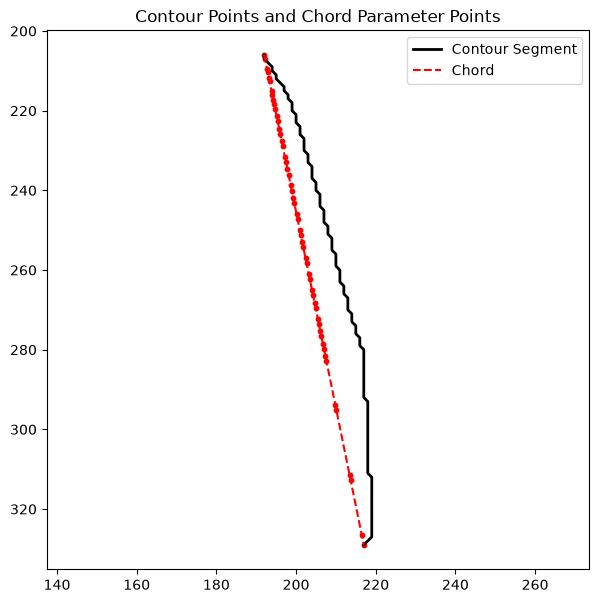

In [289]:
# 第 58–59 步：在 chord 上计算每个 t 对应的点
chord_points = (1 - t[:, None]) * S + t[:, None] * E
print("chord_points.shape =", chord_points.shape)

plt.figure(figsize=(7, 7))
plt.plot(segment[:, 0], segment[:, 1], color="black", linewidth=2, label="Contour Segment")
plt.plot(chord_points[:, 0], chord_points[:, 1], color="red", linestyle="--", label="Chord")
plt.scatter(chord_points[:, 0], chord_points[:, 1], color="red", s=10)
plt.gca().invert_yaxis()
plt.axis("equal")
plt.legend()
plt.title("Contour Points and Chord Parameter Points")
plt.show()


point_distances = [0.         0.20543424 1.38017576 1.17564714 1.96795216 1.76347072
 3.34811964 3.14355789 3.93590433 3.73137055 4.52369912 4.11476501
 4.9070037  4.49826631 5.29041215 4.88184929 5.67390342 5.06144181
 5.85328225 5.44520635 6.2369591  5.62518649 6.41670491 6.00906219
 6.80050542 6.18934482 6.98054633 6.36983341 7.16078263 6.75381314
 7.54471264 6.93451443 7.72516535 7.11537887 7.90577624 7.29639432
 8.08653473 7.68041507 8.47054403 7.86156723 8.65144914 8.24558496
 9.03546739 8.62960296 9.41948584 9.01362119 9.80350447 7.37663013
 8.16320577 4.5872097  5.3551496  2.58880561 0.        ]
d_ave = 5.7158


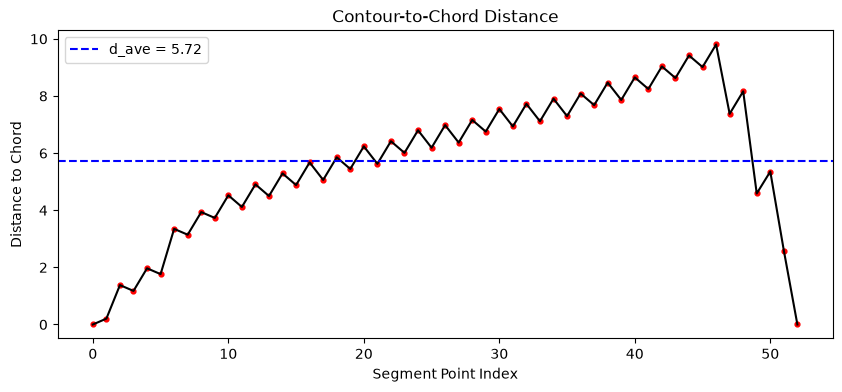

In [290]:
# 第 60–62 步：计算 point distances 和平均弦偏差 d_ave
point_distances = np.linalg.norm(segment.astype(np.float64) - chord_points, axis=1)
d_ave = np.mean(point_distances)
print("point_distances =", point_distances)
print(f"d_ave = {d_ave:.4f}")

plt.figure(figsize=(10, 4))
plt.plot(point_distances, color="black")
plt.scatter(np.arange(len(point_distances)), point_distances, color="red", s=12)
plt.axhline(d_ave, color="blue", linestyle="--", label=f"d_ave = {d_ave:.2f}")
plt.xlabel("Segment Point Index")
plt.ylabel("Distance to Chord")
plt.title("Contour-to-Chord Distance")
plt.legend()
plt.show()


### 第 63 步：根据 bend strength 选择曲线阶数

论文使用两个误差阈值 T1、T2 区分三类拟合。PDF 中没有给出可直接使用的具体数值，因此下面的 T1、T2 明确标记为实验参数，不冒充论文参数。


In [291]:
# 第 63–64 步：实验分类
T1 = 1.0
T2 = 3.0

if d_ave < T1:
    segment_type = "Straight Line"
elif d_ave < T2:
    segment_type = "Quadratic Bezier"
else:
    segment_type = "Cubic Bezier"
print("d_ave =", d_ave)
print("Selected model:", segment_type)


d_ave = 5.71575320651364
Selected model: Cubic Bezier


### 第 65 步：直线拟合

直线模型直接连接 S 和 E。这里保留原始 contour segment 作为参照。


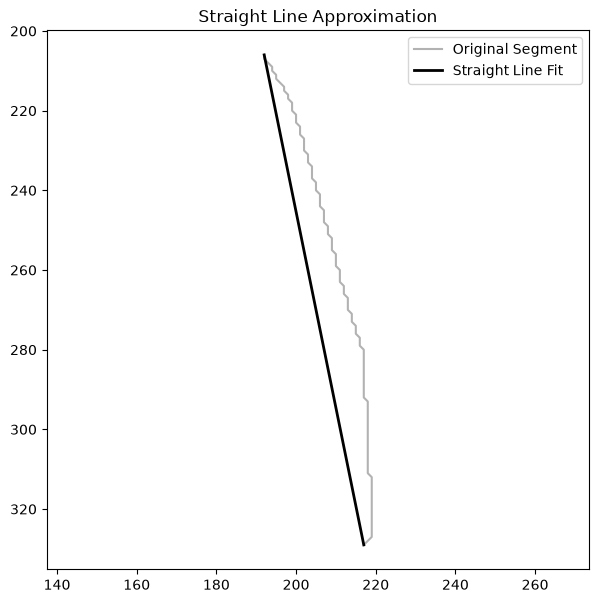

In [292]:
# 第 65 步：straight line
line_t = np.linspace(0, 1, 100)
line_points = (1 - line_t[:, None]) * S + line_t[:, None] * E

plt.figure(figsize=(7, 7))
plt.plot(segment[:, 0], segment[:, 1], color="gray", alpha=0.6, label="Original Segment")
plt.plot(line_points[:, 0], line_points[:, 1], color="black", linewidth=2, label="Straight Line Fit")
plt.gca().invert_yaxis()
plt.axis("equal")
plt.legend()
plt.title("Straight Line Approximation")
plt.show()


### 第 66 步：二次 Bézier 的最小二乘控制点

固定 P0=S、P2=E 后，二次 Bézier 为：

`B(t) = (1-t)^2 S + 2(1-t)t P1 + t^2 E`

因此每个 contour 点都可以对未知控制点 P1 建立一个线性方程，使用 `np.linalg.lstsq` 求解。


In [293]:
# 第 66 步：quadratic Bezier least squares fit
quadratic_basis = 2 * (1 - t) * t
quadratic_target = segment.astype(np.float64) - ((1 - t[:, None]) ** 2) * S - (t[:, None] ** 2) * E
P1_quadratic, residuals_q, rank_q, singular_values_q = np.linalg.lstsq(
    quadratic_basis[:, None], quadratic_target, rcond=None
)
P1_quadratic = P1_quadratic[0]
quadratic_fit = ((1 - t[:, None]) ** 2) * S + quadratic_basis[:, None] * P1_quadratic + (t[:, None] ** 2) * E
print("P0 =", S)
print("P1 =", P1_quadratic)
print("P2 =", E)
print("rank =", rank_q)


P0 = [192. 206.]
P1 = [220.42009195 262.55381533]
P2 = [217. 329.]
rank = 1


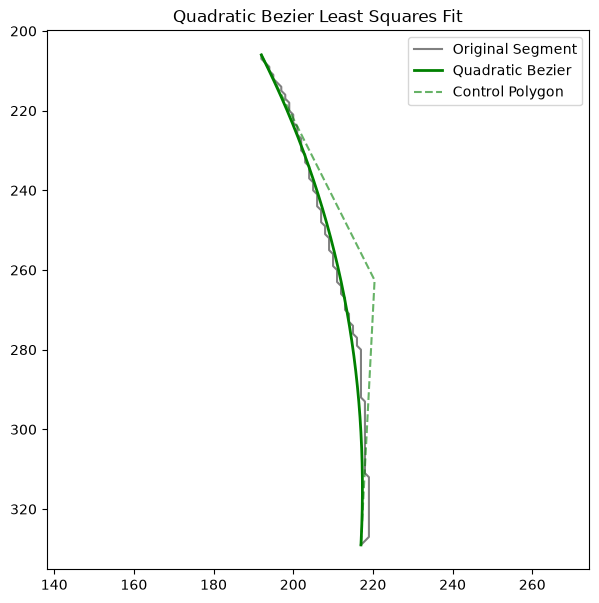

In [294]:
# 第 67 步：绘制二次 Bézier 拟合
bezier_t = np.linspace(0, 1, 200)
quadratic_curve = ((1 - bezier_t[:, None]) ** 2) * S + 2 * (1 - bezier_t[:, None]) * bezier_t[:, None] * P1_quadratic + (bezier_t[:, None] ** 2) * E
plt.figure(figsize=(7, 7))
plt.plot(segment[:, 0], segment[:, 1], color="gray", label="Original Segment")
plt.plot(quadratic_curve[:, 0], quadratic_curve[:, 1], color="green", linewidth=2, label="Quadratic Bezier")
plt.plot([S[0], P1_quadratic[0], E[0]], [S[1], P1_quadratic[1], E[1]], "g--", alpha=0.6, label="Control Polygon")
plt.gca().invert_yaxis(); plt.axis("equal"); plt.legend(); plt.title("Quadratic Bezier Least Squares Fit"); plt.show()


### 第 68 步：三次 Bézier 的最小二乘控制点

固定 P0=S、P3=E，三次 Bézier 为：

`B(t) = (1-t)^3 S + 3(1-t)^2 t P1 + 3(1-t)t^2 P2 + t^3 E`

这里 P1、P2 是两个未知二维控制点。对每个 contour 点建立两个基函数，再用最小二乘同时求出 P1、P2。


In [295]:
# 第 68 步：cubic Bezier least squares fit
cubic_basis = np.column_stack((3 * (1 - t) ** 2 * t, 3 * (1 - t) * t ** 2))
cubic_target = segment.astype(np.float64) - ((1 - t[:, None]) ** 3) * S - (t[:, None] ** 3) * E
control_points_cubic, residuals_c, rank_c, singular_values_c = np.linalg.lstsq(
    cubic_basis, cubic_target, rcond=None
)
P1_cubic = control_points_cubic[0]
P2_cubic = control_points_cubic[1]
cubic_fit = ((1 - t[:, None]) ** 3) * S + cubic_basis[:, 0, None] * P1_cubic + cubic_basis[:, 1, None] * P2_cubic + (t[:, None] ** 3) * E
print("P0 =", S)
print("P1 =", P1_cubic)
print("P2 =", P2_cubic)
print("P3 =", E)
print("rank =", rank_c)


P0 = [192. 206.]
P1 = [209.57390139 243.15084402]
P2 = [221.04952812 285.4136414 ]
P3 = [217. 329.]
rank = 2


Cubic least-squares mean error = 0.6677


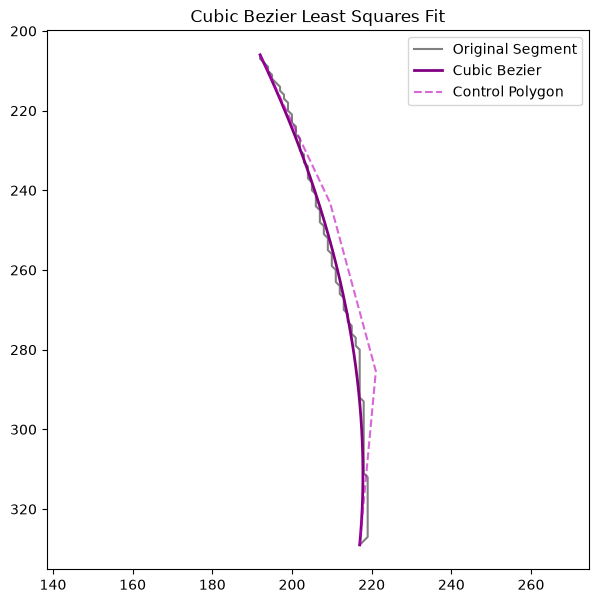

In [296]:
# 第 69 步：绘制三次 Bézier 拟合并计算拟合误差
cubic_curve = ((1 - bezier_t[:, None]) ** 3) * S + 3 * (1 - bezier_t[:, None]) ** 2 * bezier_t[:, None] * P1_cubic + 3 * (1 - bezier_t[:, None]) * bezier_t[:, None] ** 2 * P2_cubic + bezier_t[:, None] ** 3 * E
cubic_error = np.mean(np.linalg.norm(cubic_fit - segment.astype(np.float64), axis=1))
print(f"Cubic least-squares mean error = {cubic_error:.4f}")
plt.figure(figsize=(7, 7))
plt.plot(segment[:, 0], segment[:, 1], color="gray", label="Original Segment")
plt.plot(cubic_curve[:, 0], cubic_curve[:, 1], color="purple", linewidth=2, label="Cubic Bezier")
plt.plot([S[0], P1_cubic[0], P2_cubic[0], E[0]], [S[1], P1_cubic[1], P2_cubic[1], E[1]], "m--", alpha=0.6, label="Control Polygon")
plt.gca().invert_yaxis(); plt.axis("equal"); plt.legend(); plt.title("Cubic Bezier Least Squares Fit"); plt.show()


### 第 70 步：批量切分所有闭合 contour segments

最后一个 segment 使用 `np.concatenate` 跨过 contour 数组末尾，连接回第一个 feature point。


In [297]:
# 第 70 步：生成所有闭合 contour segments
all_segments = []
number_of_points = len(contour1)
for i in range(len(final_peak_indices)):
    start = final_peak_indices[i]
    end = final_peak_indices[(i + 1) % len(final_peak_indices)]
    if start < end:
        current_segment = contour1[start:end + 1]
    else:
        current_segment = np.concatenate((contour1[start:], contour1[:end + 1]), axis=0)
    all_segments.append(current_segment)
    print(f"Segment {i+1}: FP{i+1} -> FP{(i+1) % len(final_peak_indices) + 1}, shape = {current_segment.shape}")


Segment 1: FP1 -> FP2, shape = (53, 2)
Segment 2: FP2 -> FP3, shape = (25, 2)
Segment 3: FP3 -> FP4, shape = (100, 2)
Segment 4: FP4 -> FP5, shape = (3, 2)
Segment 5: FP5 -> FP6, shape = (93, 2)
Segment 6: FP6 -> FP7, shape = (6, 2)
Segment 7: FP7 -> FP8, shape = (26, 2)
Segment 8: FP8 -> FP9, shape = (60, 2)
Segment 9: FP9 -> FP10, shape = (47, 2)
Segment 10: FP10 -> FP11, shape = (43, 2)
Segment 11: FP11 -> FP12, shape = (45, 2)
Segment 12: FP12 -> FP13, shape = (38, 2)
Segment 13: FP13 -> FP1, shape = (22, 2)


## Section 4 continued: Approximation of all contour segments

前面已经完成一个 segment 的推导。现在把相同的步骤应用到闭合轮廓的每一段，并保存每一段的控制点和误差。


In [298]:
# 第 71 步：准备三类拟合的公共参数
# T1、T2 仍然是实验参数；后续替换论文给出的阈值时只需修改这里。
T1 = 1.0
T2 = 3.0
fit_results = []
print("Number of segments:", len(all_segments))


Number of segments: 13


In [299]:
# 第 72 步：定义一个 segment 的弦长参数和 bend strength
# 这里先保持代码展开式，便于逐项检查论文公式。
for segment_id, current_segment in enumerate(all_segments):
    current_segment = current_segment.astype(np.float64)
    current_S = current_segment[0]
    current_E = current_segment[-1]
    current_lengths = np.linalg.norm(np.diff(current_segment, axis=0), axis=1)
    current_accumulated = np.concatenate(([0.0], np.cumsum(current_lengths)))
    current_total = current_accumulated[-1]
    if current_total == 0:
        current_t = np.zeros(len(current_segment))
    else:
        current_t = current_accumulated / current_total
    current_chord = (1 - current_t[:, None]) * current_S + current_t[:, None] * current_E
    current_distances = np.linalg.norm(current_segment - current_chord, axis=1)
    current_d_ave = np.mean(current_distances)
    if current_d_ave < T1:
        current_type = "line"
    elif current_d_ave < T2:
        current_type = "quadratic"
    else:
        current_type = "cubic"
    print(f"Segment {segment_id + 1}: d_ave = {current_d_ave:.4f}, type = {current_type}")


Segment 1: d_ave = 5.7158, type = cubic
Segment 2: d_ave = 1.7744, type = quadratic
Segment 3: d_ave = 18.1725, type = cubic
Segment 4: d_ave = 1.0000, type = quadratic
Segment 5: d_ave = 13.0426, type = cubic
Segment 6: d_ave = 0.3170, type = line
Segment 7: d_ave = 2.6204, type = quadratic
Segment 8: d_ave = 4.2977, type = cubic
Segment 9: d_ave = 17.5247, type = cubic
Segment 10: d_ave = 9.6910, type = cubic
Segment 11: d_ave = 9.1265, type = cubic
Segment 12: d_ave = 14.4376, type = cubic
Segment 13: d_ave = 6.7918, type = cubic


### 第 73 步：对所有 segment 执行最小二乘 Bézier 拟合

对于二次曲线固定 `P0=S, P2=E`，只求 `P1`；对于三次曲线固定 `P0=S, P3=E`，求 `P1, P2`。每段结果统一保存，方便后续重新绘制整条轮廓。


In [300]:
# 第 73 步：批量求解每段的控制点
fit_results = []
for segment_id, current_segment in enumerate(all_segments):
    current_segment = current_segment.astype(np.float64)
    current_S = current_segment[0]
    current_E = current_segment[-1]
    current_lengths = np.linalg.norm(np.diff(current_segment, axis=0), axis=1)
    current_accumulated = np.concatenate(([0.0], np.cumsum(current_lengths)))
    current_total = current_accumulated[-1]
    current_t = current_accumulated / current_total if current_total else np.zeros(len(current_segment))
    current_chord = (1 - current_t[:, None]) * current_S + current_t[:, None] * current_E
    current_distances = np.linalg.norm(current_segment - current_chord, axis=1)
    current_d_ave = np.mean(current_distances)

    if current_d_ave < T1:
        current_type = "line"
        current_controls = np.array([current_S, current_E])
        current_fit = current_chord
    elif current_d_ave < T2:
        current_type = "quadratic"
        basis = 2 * (1 - current_t) * current_t
        target = current_segment - (1 - current_t[:, None]) ** 2 * current_S - current_t[:, None] ** 2 * current_E
        solved = np.linalg.lstsq(basis[:, None], target, rcond=None)[0][0]
        current_controls = np.array([current_S, solved, current_E])
        current_fit = ((1 - current_t[:, None]) ** 2 * current_S + basis[:, None] * solved + current_t[:, None] ** 2 * current_E)
    else:
        current_type = "cubic"
        basis = np.column_stack((3 * (1 - current_t) ** 2 * current_t, 3 * (1 - current_t) * current_t ** 2))
        target = current_segment - (1 - current_t[:, None]) ** 3 * current_S - current_t[:, None] ** 3 * current_E
        solved = np.linalg.lstsq(basis, target, rcond=None)[0]
        current_controls = np.array([current_S, solved[0], solved[1], current_E])
        current_fit = ((1 - current_t[:, None]) ** 3 * current_S + basis[:, 0, None] * solved[0] + basis[:, 1, None] * solved[1] + current_t[:, None] ** 3 * current_E)

    current_error = np.mean(np.linalg.norm(current_fit - current_segment, axis=1))
    fit_results.append({
        "segment_id": segment_id + 1,
        "type": current_type,
        "d_ave": current_d_ave,
        "controls": current_controls,
        "parameter": current_t,
        "source": current_segment,
        "fit": current_fit,
        "error": current_error,
    })


In [301]:
# 第 74 步：检查所有 segment 的分类、控制点数量和拟合误差
for result in fit_results:
    print(
        f"Segment {result['segment_id']}: "
        f"{result['type']}, "
        f"d_ave={result['d_ave']:.4f}, "
        f"controls={len(result['controls'])}, "
        f"fit_error={result['error']:.4f}"
    )


Segment 1: cubic, d_ave=5.7158, controls=4, fit_error=0.6677
Segment 2: quadratic, d_ave=1.7744, controls=3, fit_error=1.3210
Segment 3: cubic, d_ave=18.1725, controls=4, fit_error=3.4618
Segment 4: quadratic, d_ave=1.0000, controls=3, fit_error=0.0000
Segment 5: cubic, d_ave=13.0426, controls=4, fit_error=2.9041
Segment 6: line, d_ave=0.3170, controls=2, fit_error=0.3170
Segment 7: quadratic, d_ave=2.6204, controls=3, fit_error=1.9856
Segment 8: cubic, d_ave=4.2977, controls=4, fit_error=0.9977
Segment 9: cubic, d_ave=17.5247, controls=4, fit_error=2.0070
Segment 10: cubic, d_ave=9.6910, controls=4, fit_error=0.8822
Segment 11: cubic, d_ave=9.1265, controls=4, fit_error=0.6632
Segment 12: cubic, d_ave=14.4376, controls=4, fit_error=1.1998
Segment 13: cubic, d_ave=6.7918, controls=4, fit_error=1.0504


### 第 75 步：逐段检查 Bézier 拟合结果

灰色是原始轮廓点，彩色是拟合曲线；控制多边形用虚线显示。这样可以检查分类阈值是否造成明显欠拟合。


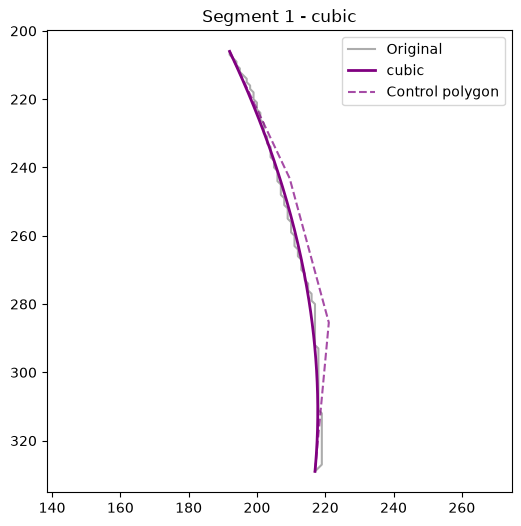

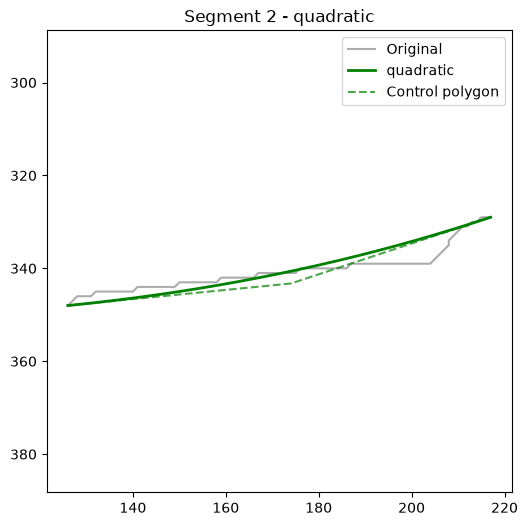

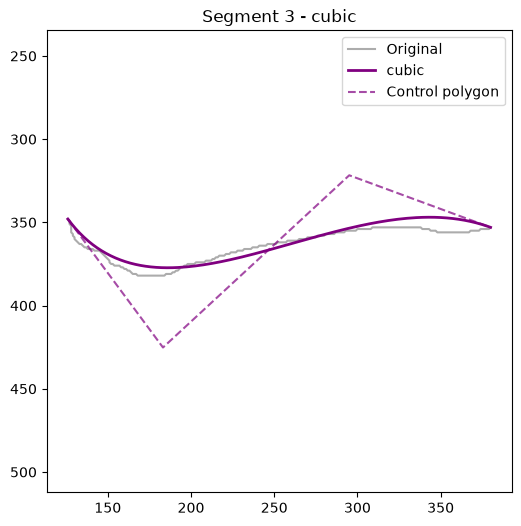

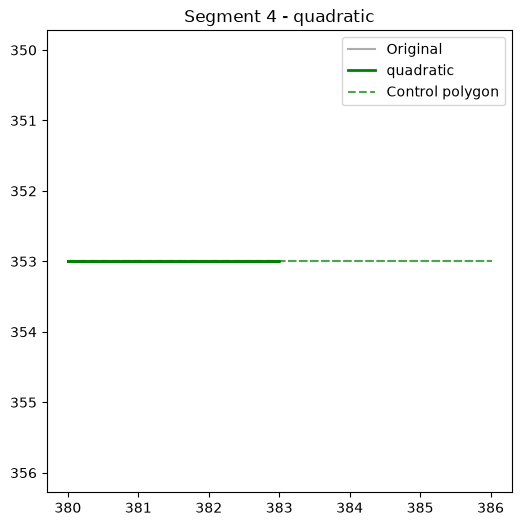

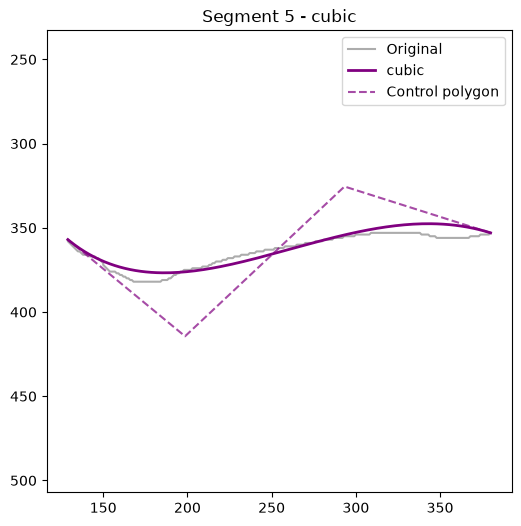

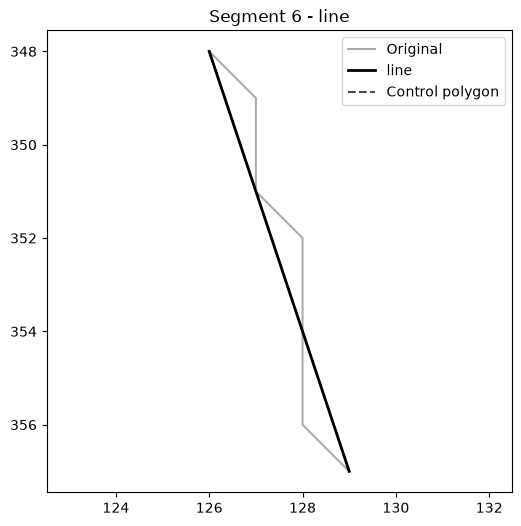

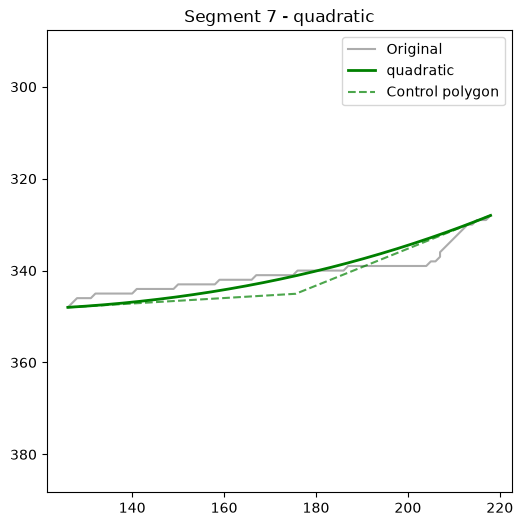

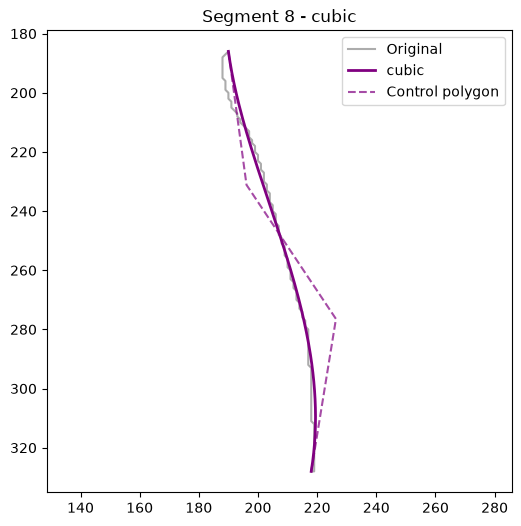

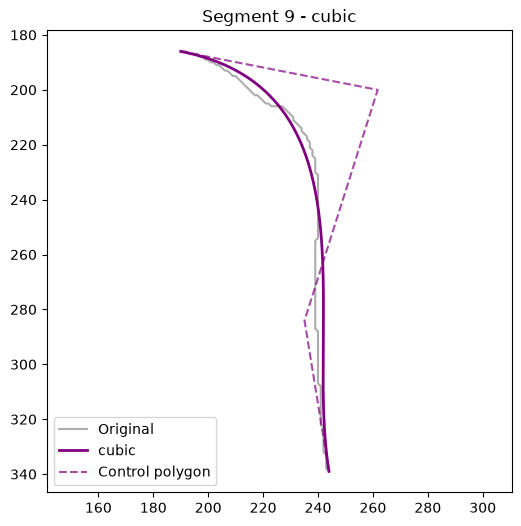

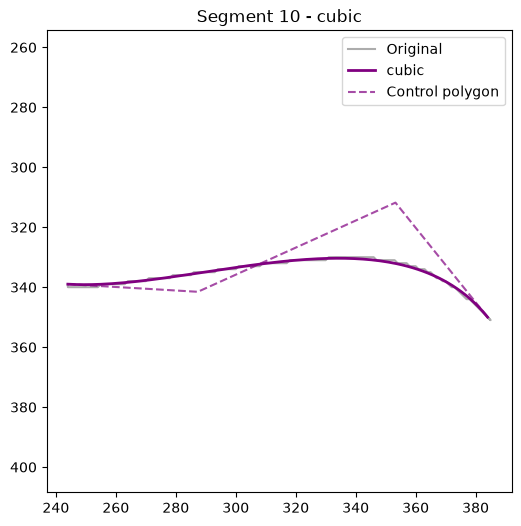

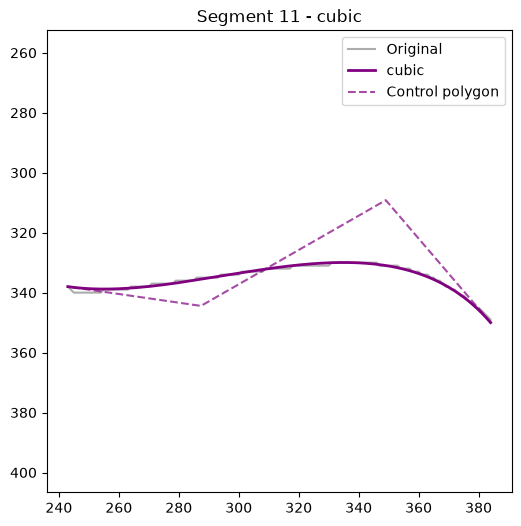

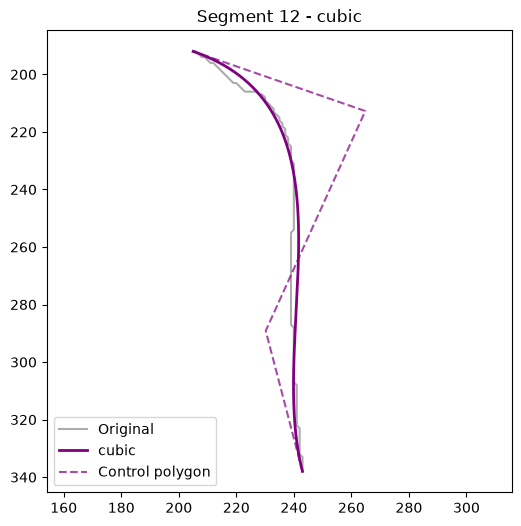

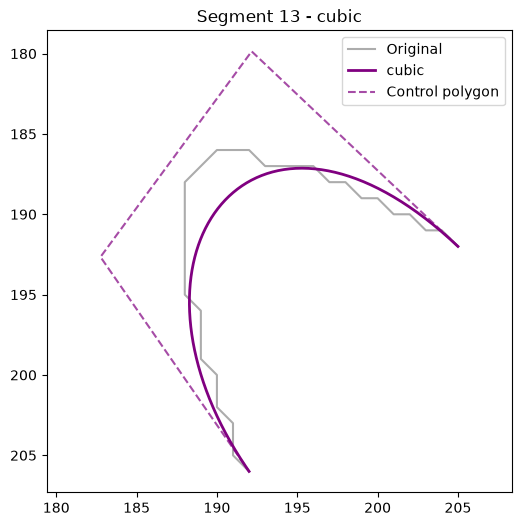

In [302]:
# 第 75 步：每个 segment 的原始点、拟合曲线和控制多边形
for result in fit_results:
    controls = result["controls"]
    curve_t = np.linspace(0, 1, 150)
    if result["type"] == "line":
        curve = (1 - curve_t[:, None]) * controls[0] + curve_t[:, None] * controls[1]
        color = "black"
    elif result["type"] == "quadratic":
        curve = ((1 - curve_t[:, None]) ** 2 * controls[0] + 2 * (1 - curve_t[:, None]) * curve_t[:, None] * controls[1] + curve_t[:, None] ** 2 * controls[2])
        color = "green"
    else:
        curve = ((1 - curve_t[:, None]) ** 3 * controls[0] + 3 * (1 - curve_t[:, None]) ** 2 * curve_t[:, None] * controls[1] + 3 * (1 - curve_t[:, None]) * curve_t[:, None] ** 2 * controls[2] + curve_t[:, None] ** 3 * controls[3])
        color = "purple"
    plt.figure(figsize=(6, 6))
    plt.plot(result["source"][:, 0], result["source"][:, 1], color="gray", alpha=0.65, label="Original")
    plt.plot(curve[:, 0], curve[:, 1], color=color, linewidth=2, label=result["type"])
    plt.plot(controls[:, 0], controls[:, 1], "--", color=color, alpha=0.7, label="Control polygon")
    plt.gca().invert_yaxis(); plt.axis("equal"); plt.legend()
    plt.title(f"Segment {result['segment_id']} - {result['type']}")
    plt.show()


### 第 76 步：把所有拟合曲线重新组合成字符轮廓

每一段只取参数 `0 <= t < 1` 的部分，避免相邻 segments 的端点重复；最后一个 segment 再补回闭合起点。


In [303]:
# 第 76 步：重建整条近似轮廓
approximation_parts = []
for result in fit_results:
    controls = result["controls"]
    curve_t = np.linspace(0, 1, 80, endpoint=False)
    if result["type"] == "line":
        curve = (1 - curve_t[:, None]) * controls[0] + curve_t[:, None] * controls[1]
    elif result["type"] == "quadratic":
        curve = ((1 - curve_t[:, None]) ** 2 * controls[0] + 2 * (1 - curve_t[:, None]) * curve_t[:, None] * controls[1] + curve_t[:, None] ** 2 * controls[2])
    else:
        curve = ((1 - curve_t[:, None]) ** 3 * controls[0] + 3 * (1 - curve_t[:, None]) ** 2 * curve_t[:, None] * controls[1] + 3 * (1 - curve_t[:, None]) * curve_t[:, None] ** 2 * controls[2] + curve_t[:, None] ** 3 * controls[3])
    approximation_parts.append(curve)
approximation_contour = np.concatenate(approximation_parts, axis=0)
approximation_contour = np.vstack((approximation_contour, approximation_contour[0]))
print("approximation_contour.shape =", approximation_contour.shape)


approximation_contour.shape = (1041, 2)


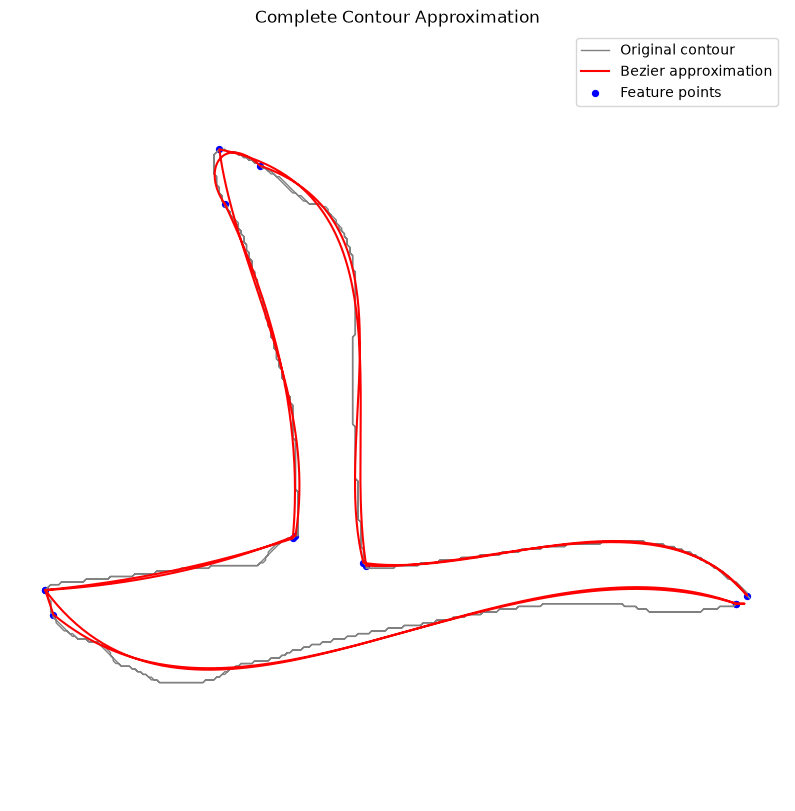

In [304]:
# 第 77 步：原始 contour 与 Bézier 近似轮廓总览
plt.figure(figsize=(10, 10))
plt.plot(contour1[:, 0], contour1[:, 1], color="gray", linewidth=1, label="Original contour")
plt.plot(approximation_contour[:, 0], approximation_contour[:, 1], color="red", linewidth=1.5, label="Bezier approximation")
plt.scatter(contour1[final_peak_indices, 0], contour1[final_peak_indices, 1], color="blue", s=18, label="Feature points")
plt.gca().invert_yaxis(); plt.axis("equal"); plt.axis("off"); plt.legend()
plt.title("Complete Contour Approximation")
plt.show()


### 第 78 步：统计 Section 4 的结果

这里统计三种模型的数量，并报告平均拟合误差，作为后续调整 `T1`、`T2` 或继续实现 Section 5 的依据。


In [305]:
# 第 78 步：汇总统计
type_counts = {
    "line": sum(result["type"] == "line" for result in fit_results),
    "quadratic": sum(result["type"] == "quadratic" for result in fit_results),
    "cubic": sum(result["type"] == "cubic" for result in fit_results),
}
mean_fit_error = np.mean([result["error"] for result in fit_results])
print("Model counts:", type_counts)
print(f"Mean segment fit error = {mean_fit_error:.4f}")


Model counts: {'line': 1, 'quadratic': 3, 'cubic': 9}
Mean segment fit error = 1.3429
